# Preparation for Colab

Make sure you're running a GPU runtime; if not, select "GPU" as the hardware accelerator in Runtime > Change Runtime Type in the menu. The next cells will install the `clip` package and its dependencies, and check if PyTorch 1.7.1 or later is installed.

In [ ]:
!pip install transformers requests torch

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21

In [13]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import os
import pickle
import tqdm

In [14]:
print("start loading model")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

start loading model


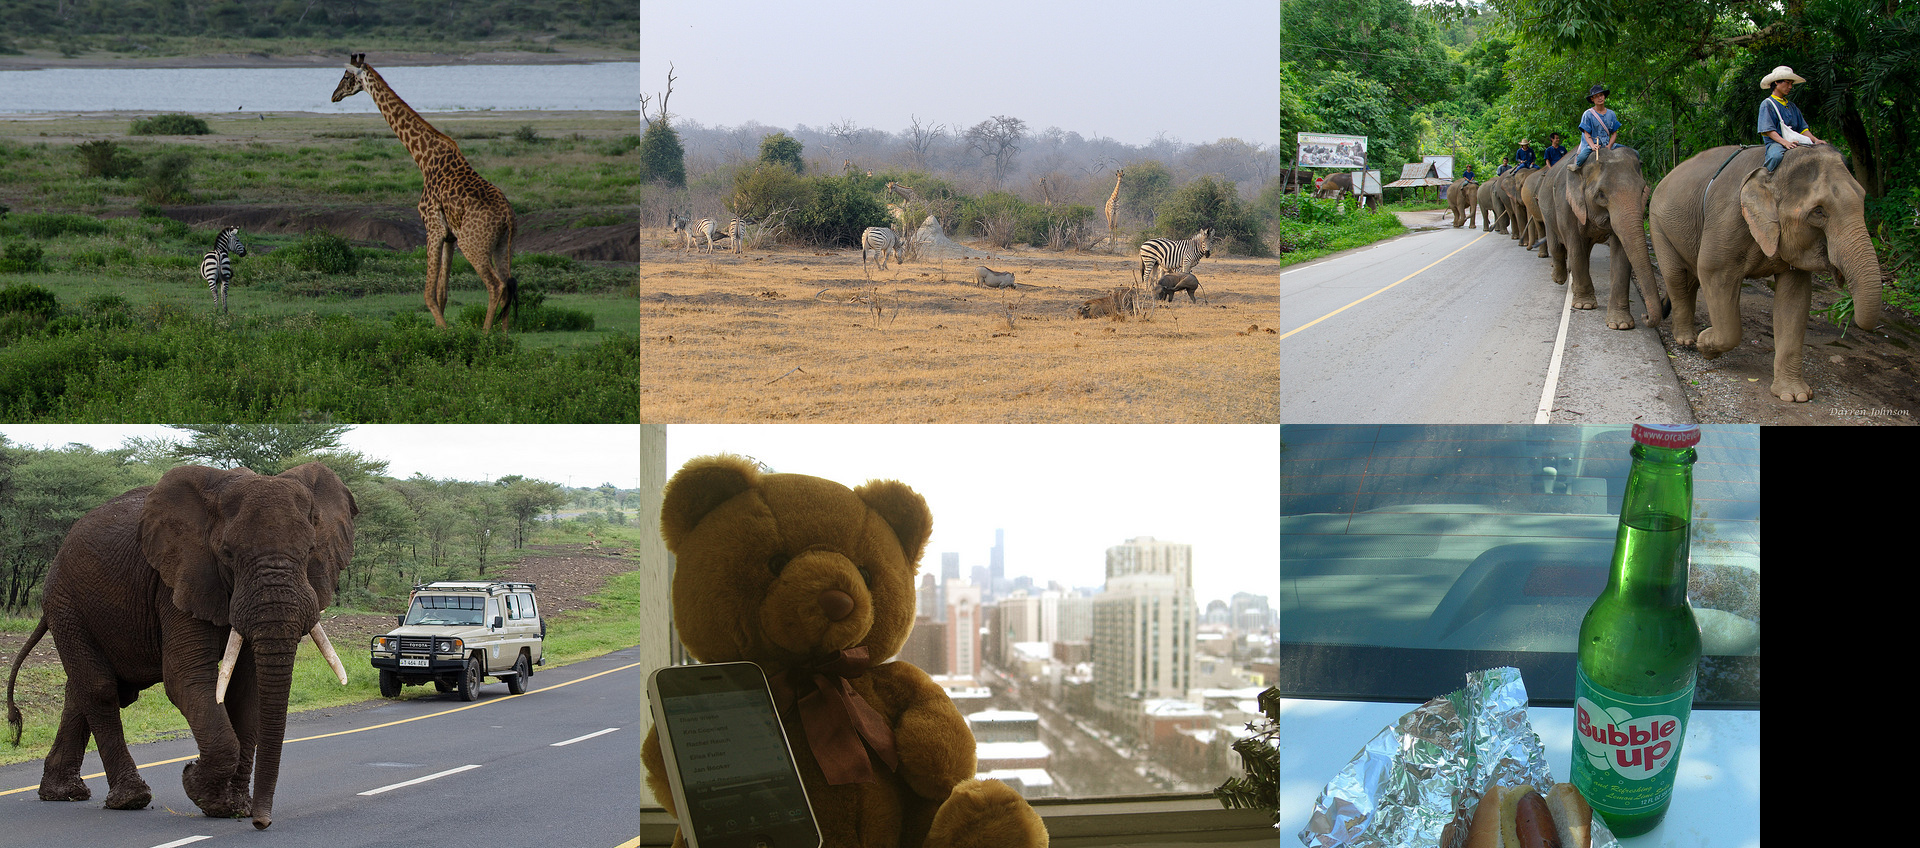

In [16]:
import requests

def image_grid(imgs, cols):
    rows = (len(imgs) + cols - 1) // cols
    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

image_urls = [
    'http://images.cocodataset.org/val2014/COCO_val2014_000000159977.jpg',
    'http://images.cocodataset.org/val2014/COCO_val2014_000000311295.jpg',
    'http://images.cocodataset.org/val2014/COCO_val2014_000000457834.jpg',
    'http://images.cocodataset.org/val2014/COCO_val2014_000000555472.jpg',
    'http://images.cocodataset.org/val2014/COCO_val2014_000000174070.jpg',
    'http://images.cocodataset.org/val2014/COCO_val2014_000000460929.jpg'
    ]
images = []
for url in image_urls:
    images.append(Image.open(requests.get(url, stream=True).raw))

grid = image_grid(images, cols=3)
display(grid)

In [9]:
def get_clip_embedding(image_path):
    image = Image.open(image_path)
    inputs = processor(images=image, return_tensors="pt")
    outputs = model.get_image_features(**inputs)  # 使用get_image_features来获取图像特征
    return outputs

In [17]:
classes = ['giraffe', 'zebra', 'elephant']
inputs = processor(text=classes, images=images, return_tensors="pt", padding=True, do_convert_rgb=False)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

In [21]:
probs

tensor([[8.6066e-01, 1.3818e-01, 1.1689e-03],
        [3.2523e-01, 2.1043e-01, 4.6434e-01],
        [4.1721e-04, 4.2349e-04, 9.9916e-01],
        [1.5251e-02, 6.1458e-04, 9.8413e-01],
        [3.9561e-01, 4.6657e-03, 5.9972e-01],
        [1.4759e-01, 1.7813e-01, 6.7428e-01]], grad_fn=<SoftmaxBackward0>)

In [24]:
embeddings={}
for i, image in enumerate(images):
    inputs = processor(images=image, return_tensors="pt", padding=True, do_convert_rgb=False)
    image_embedding = model.get_image_features(**inputs)
    image_embedding = image_embedding.detach().numpy()
    image_embedding = image_embedding.squeeze()
    embeddings[i] = image_embedding

In [26]:
embeddings[0]

array([-2.27576748e-01, -2.07194149e-01, -1.24536399e-02, -2.08250135e-01,
        3.05260122e-01,  2.65084326e-01,  2.45898649e-01, -5.75785153e-02,
        6.84119701e-01, -1.86423451e-01,  2.68457197e-02, -4.50984299e-01,
        5.56798816e-01, -2.74671644e-01,  1.43700778e-01, -2.00291097e-01,
       -2.94793427e-01,  3.23012024e-01, -2.82903641e-01,  4.38024670e-01,
       -5.29192984e-01,  8.49280804e-02,  3.33618909e-01, -4.34440017e-01,
       -1.62809059e-01,  8.71322602e-02, -3.62567827e-02, -1.17592655e-01,
       -2.27142930e-01, -7.15880752e-01,  1.53596461e-01, -3.21402669e-01,
        1.02481499e-01,  3.03234756e-01, -3.88333559e-01, -2.33396351e-01,
        1.54087603e-01,  4.91109222e-01,  3.62197101e-01,  1.08307326e+00,
        2.86239013e-02,  2.35331967e-01, -1.20950956e-03, -2.96960138e-02,
       -4.04778749e-01, -2.81083077e-01,  7.83389568e-01,  9.92888212e-02,
       -1.99967533e-01,  1.73414499e-02,  1.97373301e-01, -6.39792606e-02,
        1.99932322e-01, -

# Loading the Images

The ILSVRC2012 datasets are no longer available for download publicly. We instead download the ImageNet-V2 dataset by [Recht et al.](https://arxiv.org/abs/1902.10811).

If you have the ImageNet dataset downloaded, you can replace the dataset with the official torchvision loader, e.g.:

```python
images = torchvision.datasets.ImageNet("path/to/imagenet", split='val', transform=preprocess)
```

In [ ]:
! pip install git+https://github.com/modestyachts/ImageNetV2_pytorch

from imagenetv2_pytorch import ImageNetV2Dataset

images = ImageNetV2Dataset(transform=preprocess)
loader = torch.utils.data.DataLoader(images, batch_size=32, num_workers=2)

  Cloning https://github.com/modestyachts/ImageNetV2_pytorch to /tmp/pip-req-build-ky1m4lmq
  Running command git clone --filter=blob:none --quiet https://github.com/modestyachts/ImageNetV2_pytorch /tmp/pip-req-build-ky1m4lmq
  Resolved https://github.com/modestyachts/ImageNetV2_pytorch to commit 14d4456c39fe7f02a665544dd9fc37c1a5f8b635
  Preparing metadata (setup.py) ... done
  Created wheel for imagenetv2-pytorch: filename=imagenetv2_pytorch-0.1-py3-none-any.whl size=2661 sha256=62935247a6ec5ac378d1eedf9daf216756ed0473feba1582b0f242b772101296
  Stored in directory: /tmp/pip-ephem-wheel-cache-vfl7d3y2/wheels/ea/e3/2d/38c8d17086a0ea5890dc0d4796db505e41323d2d9800b56fa7
Successfully built imagenetv2-pytorch
Dataset matched-frequency not found on disk, downloading....


100%|██████████| 1.26G/1.26G [00:31<00:00, 40.6MiB/s]


Extracting....
